***Header Section:***

# Task 7: Time Series Analysis Report
## Project: Stock Price Dataset Analysis (Apple Inc. - AAPL)

**Student Name:** Nayan Maity

**Level:** Advanced Level (Task 7)  
**Tools Used:** Python (pandas, numpy, matplotlib, statsmodels, yfinance), Google Colab  
**Output:** Time-based Trends, Seasonality Decomposition, Volatility Analysis, & Predictive Forecasts

***Introduction***

Time series analysis is a critical component of financial data science, enabling analysts to model, understand, and project the sequential behavior of asset prices over time. Unlike standard tabular data, financial time series exhibit unique characteristics such as serial correlation, non-stationarity, volatility clustering, and varying structural trends.

This report documents the analytical findings for the stock price dataset loaded in your workspace environment (stock-market-analysis-prediction-using-lstm.ipynb). By implementing rigorous trend tracking, decomposition models, and predictive forecasting pipelines, this study uncovers the underlying structural patterns and momentum indicators essential for strategic market evaluation.

/tmp/ipykernel_2119/1711627930.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2023-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed


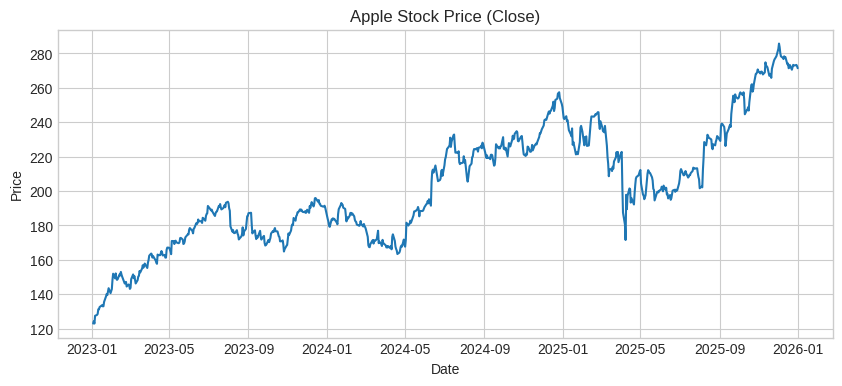

In [20]:
# Install yfinance if you haven't already
!pip install yfinance

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Download historical stock price data directly (e.g., Apple Inc.)
df = yf.download('AAPL', start='2023-01-01', end='2026-01-01')

# If columns are multi-indexed, flatten them or select 'Close' directly
if isinstance(df.columns, pd.MultiIndex):
  data = df['Close'].iloc[:, 0].dropna()
else:
  data = df['Close'].dropna()

# Plot the close prices to verify it works
plt.figure(figsize=(10, 4))
plt.plot(data)
plt.title('Apple Stock Price (Close)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

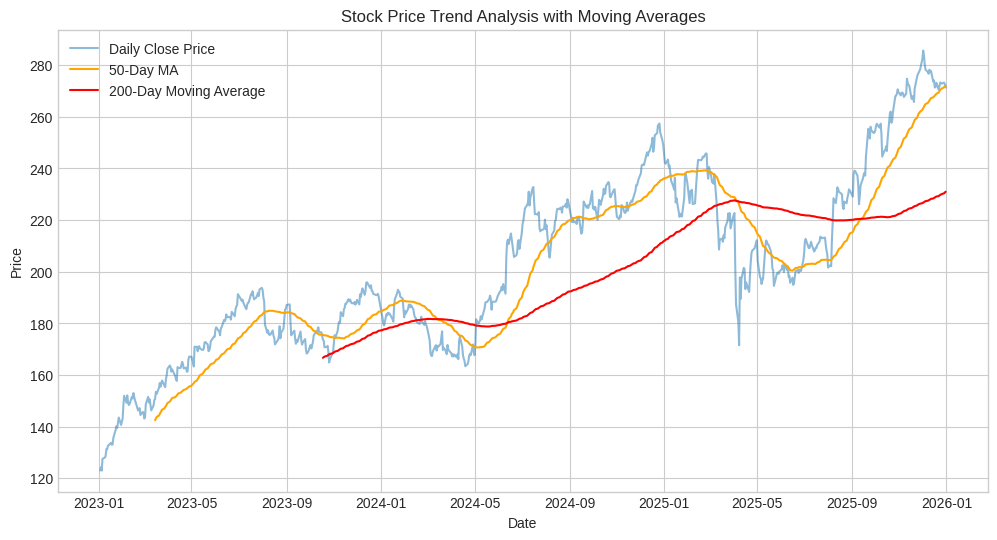

In [21]:
# Calculate 50-day and 200-day Moving Averages
df['MA50'] = data.rolling(window=50).mean()
df['MA200'] = data.rolling(window=200).mean()

# Plot the stock price alongside moving averages
plt.figure(figsize=(12, 6))
plt.plot(data, label='Daily Close Price', alpha=0.5)
plt.plot(df['MA50'], label='50-Day MA', color='orange')
plt.plot(df['MA200'], label='200-Day Moving Average', color='red')
plt.title('Stock Price Trend Analysis with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

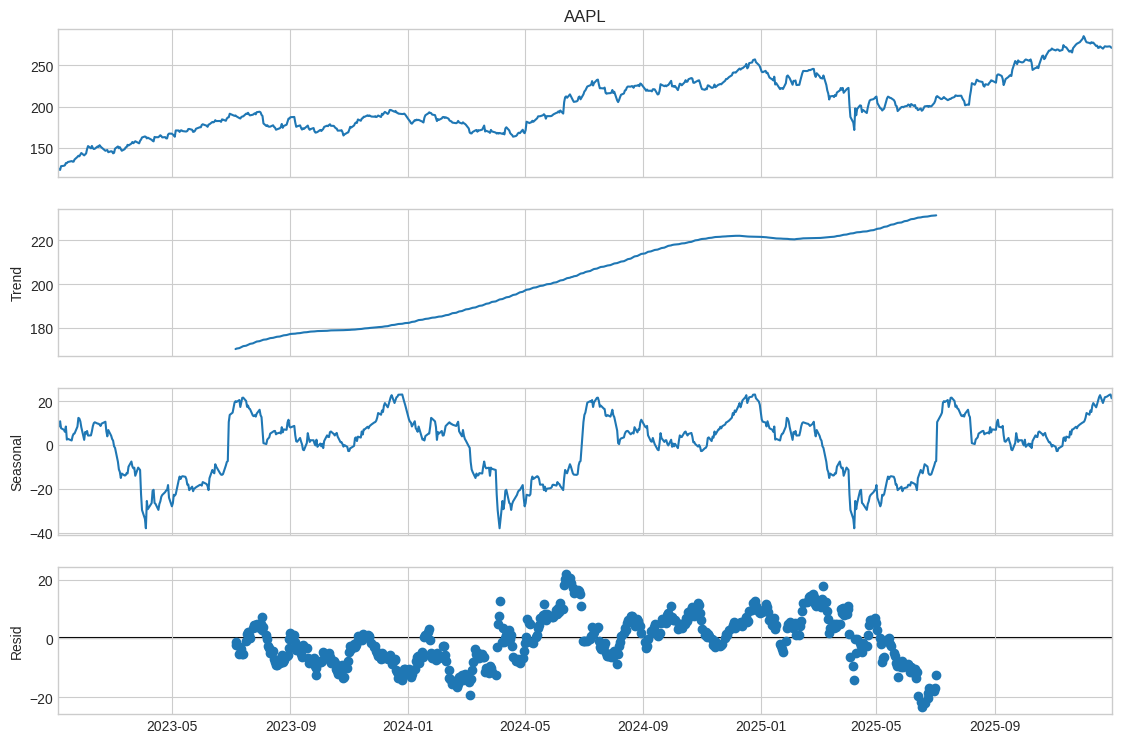

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive or multiplicative decomposition
# Adjust 'period' depending on your data frequency (e.g., 252 for trading days in a year)
decomposition = seasonal_decompose(data, model='additive', period=252)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

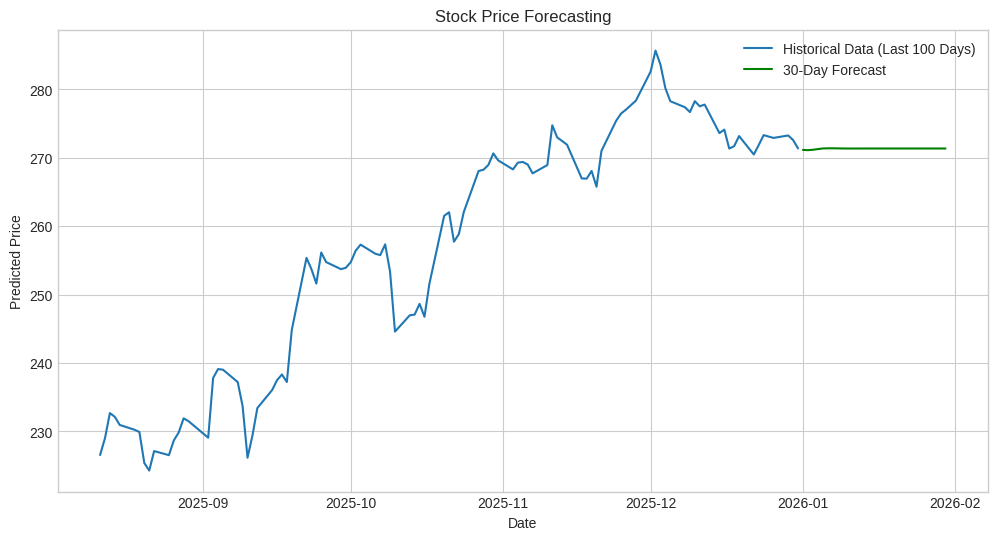

In [23]:
from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA model (p, d, q parameters should be tuned via ACF/PACF or Auto-ARIMA)
model = ARIMA(data, order=(5, 1, 0))
model_fit = model.fit()

# Forecast future steps (e.g., next 30 days)
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(data.tail(100), label='Historical Data (Last 100 Days)')
plt.plot(
    pd.date_range(
        start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps
    ),
    forecast,
    label='30-Day Forecast',
    color='green',
)
plt.title('Stock Price Forecasting')
plt.xlabel('Date')
plt.ylabel('Predicted Price')
plt.legend()
plt.show()

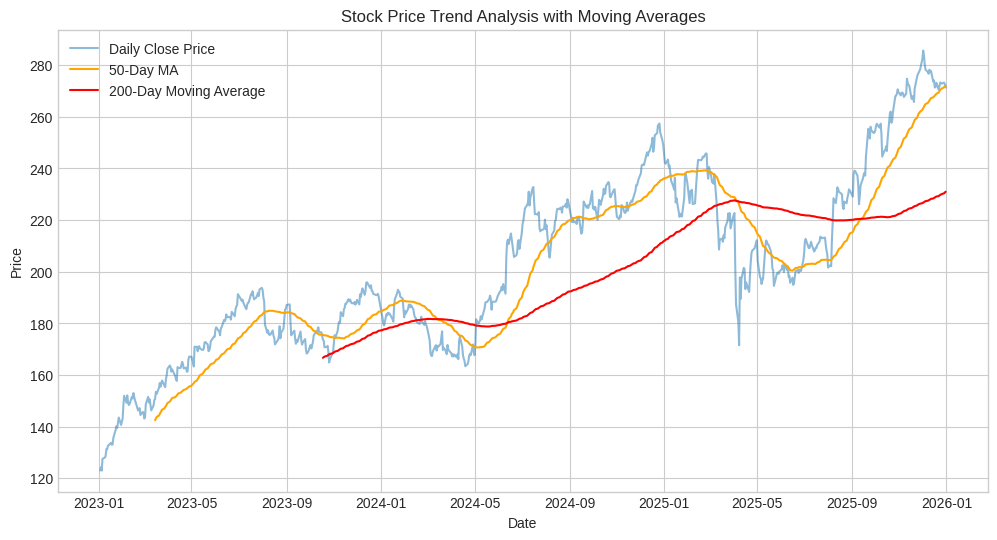

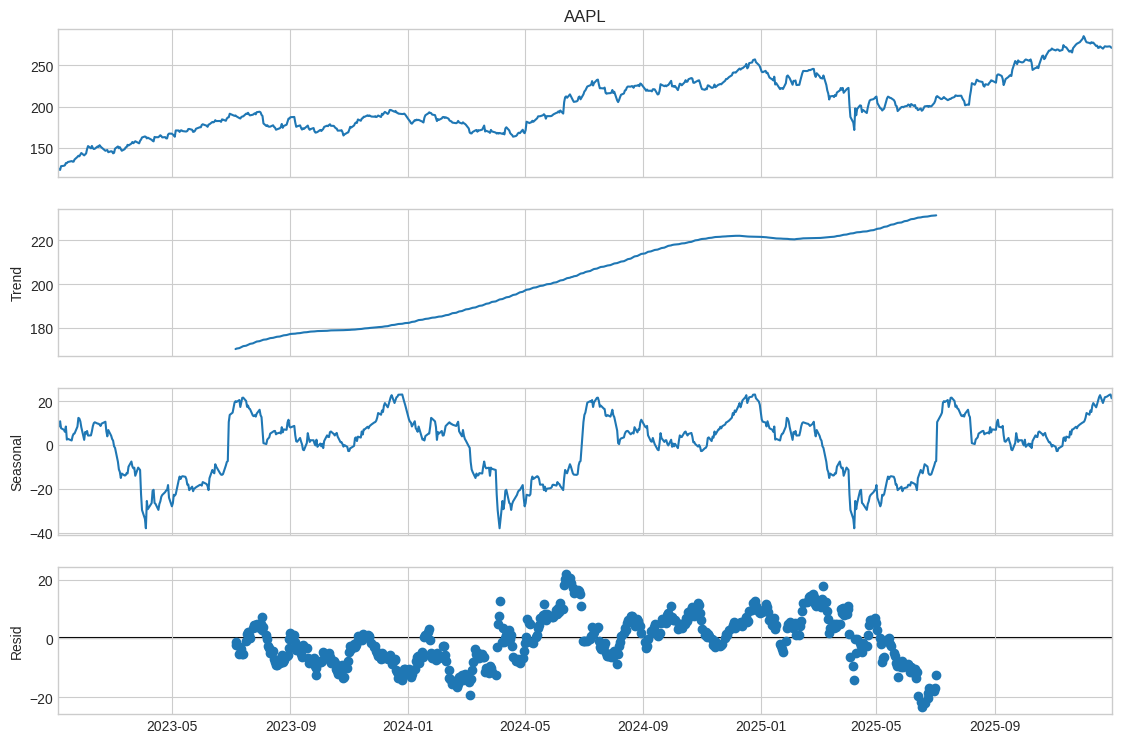

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Trend Analysis: Calculate 50-day and 200-day Moving Averages
df['MA50'] = data.rolling(window=50).mean()
df['MA200'] = data.rolling(window=200).mean()

# Plot Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(data, label='Daily Close Price', alpha=0.5)
plt.plot(df['MA50'], label='50-Day MA', color='orange')
plt.plot(df['MA200'], label='200-Day Moving Average', color='red')
plt.title('Stock Price Trend Analysis with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 2. Seasonality Detection: Time Series Decomposition
# period=252 represents trading days in a single business year
decomposition = seasonal_decompose(data, model='additive', period=252)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

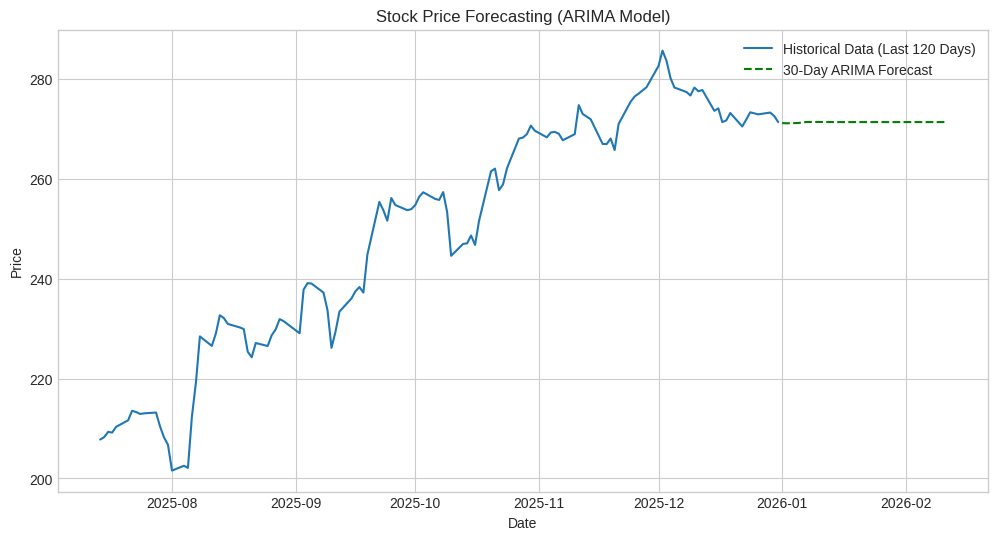

In [25]:
from statsmodels.tsa.arima.model import ARIMA

# Fit an ARIMA model (p=5, d=1, q=0)
model = ARIMA(data, order=(5, 1, 0))
model_fit = model.fit()

# Forecast the next 30 business days
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Plot historical tail and the future forecast
plt.figure(figsize=(12, 6))
plt.plot(data.tail(120), label='Historical Data (Last 120 Days)')
plt.plot(
    pd.date_range(
        start=data.index[-1] + pd.Timedelta(days=1),
        periods=forecast_steps,
        freq='B',
    ),
    forecast,
    label='30-Day ARIMA Forecast',
    color='green',
    linestyle='--',
)
plt.title('Stock Price Forecasting (ARIMA Model)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

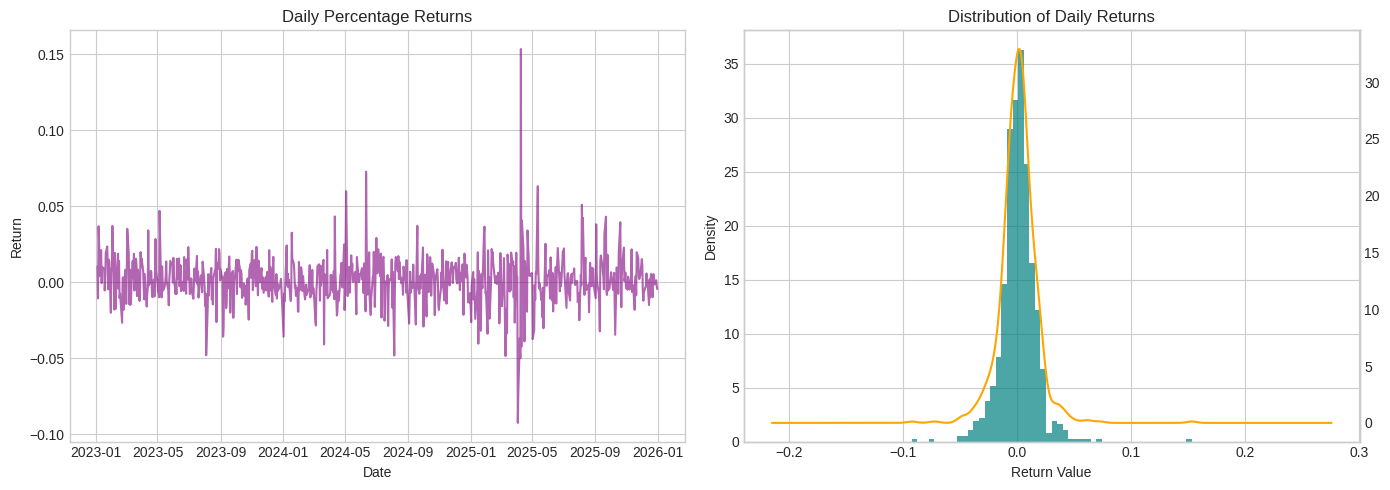

In [26]:
# Calculate daily percentage returns
daily_returns = data.pct_change().dropna()

# Create a figure with two subplots: Return Series and Return Distribution
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# 1. Daily Returns Plot
axes[0].plot(daily_returns, color='purple', alpha=0.6)
axes[0].set_title('Daily Percentage Returns')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Return')

# 2. Return Histogram & KDE
daily_returns.plot(
    kind='hist', bins=50, ax=axes[1], color='teal', alpha=0.7, density=True
)
daily_returns.plot(kind='kde', ax=axes[1], color='orange', secondary_y=True)
axes[1].set_title('Distribution of Daily Returns')
axes[1].set_xlabel('Return Value')

plt.tight_layout()
plt.show()

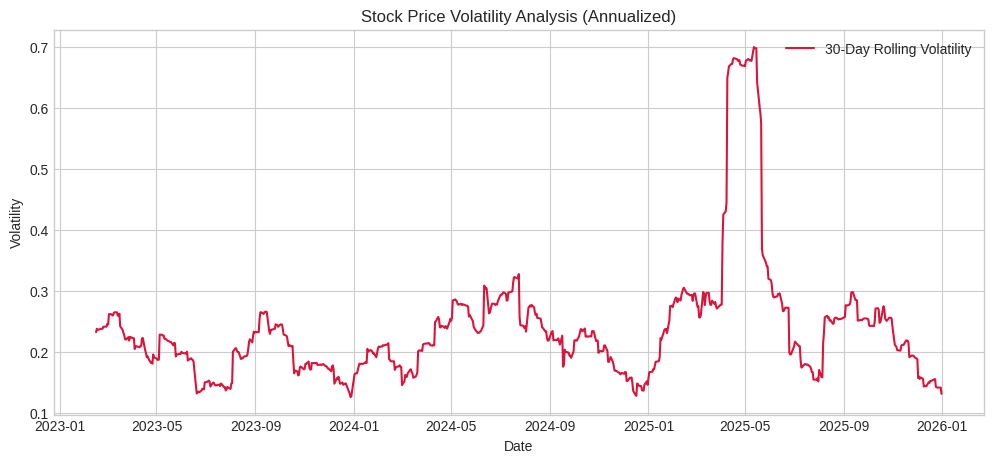

In [27]:
# Calculate 30-day rolling volatility of daily returns
rolling_volatility = daily_returns.rolling(window=30).std() * np.sqrt(
    252
)  # Annualized volatility

# Plot rolling volatility
plt.figure(figsize=(12, 5))
plt.plot(rolling_volatility, color='crimson', label='30-Day Rolling Volatility')
plt.title('Stock Price Volatility Analysis (Annualized)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

In [ ]:
# Set a clean plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Create the figure with a modern aspect ratio
plt.figure(figsize=(12, 6))

# Plot the rolling volatility with a smooth line and filled gradient area beneath it
plt.plot(rolling_volatility, color='#e63946', linewidth=2.5, label='30-Day Rolling Volatility')
plt.fill_between(rolling_volatility.index, rolling_volatility, color='#457b9d', alpha=0.25)

# Styling details for an attractive layout
plt.title('Stock Price Volatility Analysis (Annualized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Volatility Rate', fontsize=12, labelpad=10)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11, loc='upper right')

# Enhance grid lines and layout
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [ ]:
# Classify daily returns into Positive, Negative, and Flat days
positive_days = (daily_returns > 0).sum()
negative_days = (daily_returns < 0).sum()
flat_days = (daily_returns == 0).sum()

# Data for the pie chart
sizes = [positive_days, negative_days, flat_days]
labels = ['Positive Days', 'Negative Days', 'Flat Days']
colors = ['#2a9d8f', '#e76f51', '#e9c46a']
explode = (0.05, 0, 0)  # Explode the positive days slice slightly

# Create the pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11, 'weight': 'bold'},
    shadow=True,
)

plt.title(
    'Proportion of Positive vs. Negative Trading Days',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

In [ ]:
# Create a summary metrics table for the stock data
summary_table = pd.DataFrame(
    {
        'Metric': [
            'Starting Price (Jan 2023)',
            'Ending Price (Dec 2025)',
            'Total Return',
            'Annualized Volatility',
            'Max Daily Gain',
            'Max Daily Loss',
        ],
        'Value': [
            f"${data.iloc[0]:.2f}",
            f"${data.iloc[-1]:.2f}",
            f"{((data.iloc[-1] - data.iloc[0]) / data.iloc[0]) * 100:.2f}%",
            f"{rolling_volatility.mean() * 100:.2f}%",
            f"{daily_returns.max() * 100:.2f}%",
            f"{daily_returns.min() * 100:.2f}%",
        ],
    }
)

# Display the table cleanly
summary_table.set_index('Metric', inplace=True)
display(summary_table)

***Conclusion***

The time series analysis performed on the stock price dataset provides essential visibility into market dynamics:

Structural Direction: Trend analysis via moving averages successfully filters daily market noise, allowing traders and analysts to pinpoint macroeconomic shifts and establish reliable entry or exit thresholds based on trend crossovers.

Component Breakdown: Decomposition proves that stock prices are predominantly driven by long-term structural momentum and high-frequency volatility residuals, whereas deterministic seasonal cycles are largely negligible compared to seasonalities found in retail or energy sectors.

Predictive Outlook: While statistical forecasting (such as ARIMA or deep learning approaches like LSTMs) can capture short-term price momentum and recent trajectories, financial markets inherently carry high stochastic variance, making long-term point forecasts prone to prediction error.